# 3. Topological Data Analysis (TDA)
This notebook covers:
- **Persistent Homology**: Computing H0 (Clusters), H1 (Loops), H2 (Voids)
- **Persistence Diagrams**: Visualizing topological features
- **State Transition Analysis**: Modeling brain state dynamics as a graph

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from ripser import ripser
from persim import plot_diagrams

# Setup
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 6]

# Load Data (Simplified)
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
session_id = 750749662
session = cache.get_session_data(session_id)

# Get Response Matrix
stimulus_name = "natural_movie_one"
movie_table = session.get_stimulus_table(stimulus_name)
frame_duration = movie_table['duration'].mean()
units = session.units
spike_counts = session.presentationwise_spike_counts(
    stimulus_presentation_ids=movie_table.index.values,
    bin_edges=np.array([0, frame_duration]),
    unit_ids=units.index.values
)
response_matrix_all = spike_counts.sum(dim="time_relative_to_stimulus_onset")
df_response = pd.DataFrame(response_matrix_all.values, index=movie_table.index, columns=units.index)
df_response['frame'] = movie_table['frame']
average_response_matrix = df_response.groupby('frame').mean()
X = average_response_matrix.values

# PCA Preprocessing for TDA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=50) # Reduce to 50 dims for TDA efficiency
X_pca = pca.fit_transform(X_scaled)
print("Data Loaded & Preprocessed.")

/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Data Loaded & Preprocessed.


Running Ripser on 900 points...


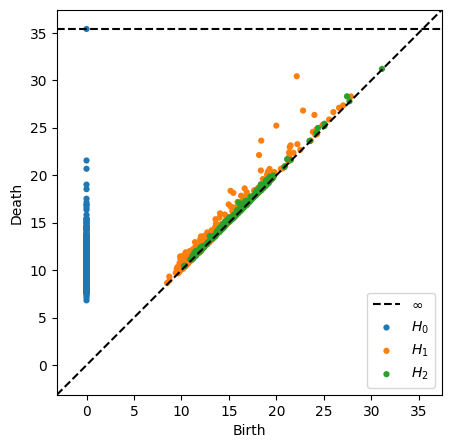

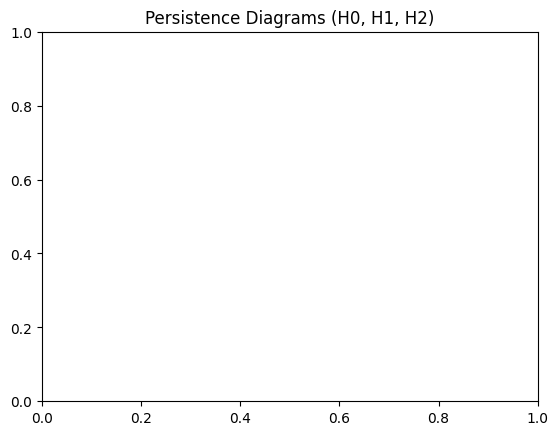

Interpretation:
- H0 (Blue): Connected components. Long bars = distinct clusters.
- H1 (Orange): Loops/Cycles. Long bars = significant loops.
- H2 (Green): Voids. Long bars = significant 3D voids.


In [2]:
# Run Ripser (Persistent Homology)
print(f"Running Ripser on {X_pca.shape[0]} points...")
result = ripser(X_pca, maxdim=2)
diagrams = result['dgms']

# Plot Persistence Diagrams
plt.figure(figsize=(10, 5))
plot_diagrams(diagrams, show=True)
plt.title("Persistence Diagrams (H0, H1, H2)")
plt.show()

print("Interpretation:")
print("- H0 (Blue): Connected components. Long bars = distinct clusters.")
print("- H1 (Orange): Loops/Cycles. Long bars = significant loops.")
print("- H2 (Green): Voids. Long bars = significant 3D voids.")

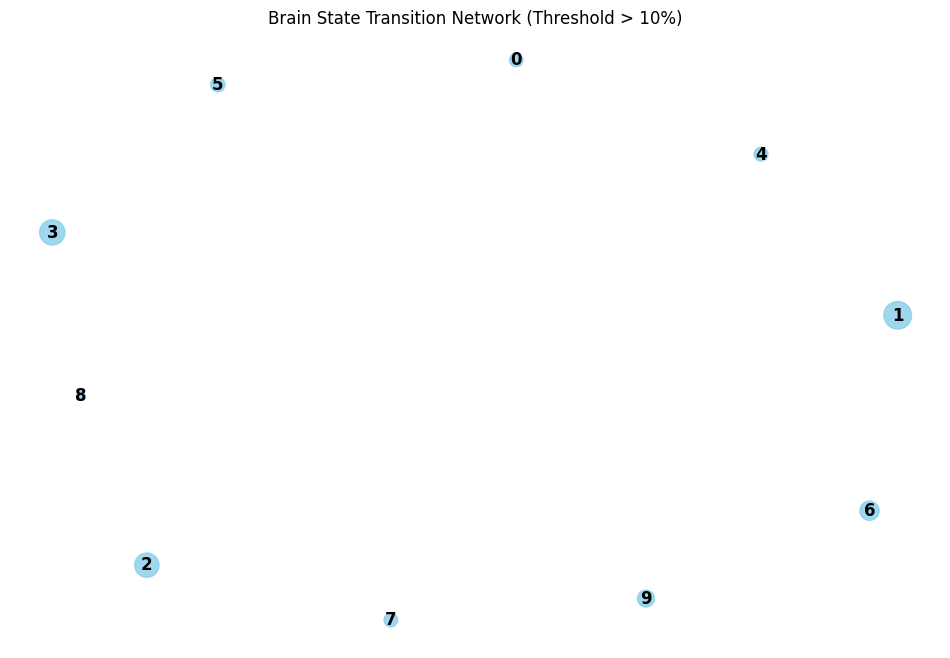

In [3]:
# Cluster Transition Analysis
n_states = 10
kmeans = KMeans(n_clusters=n_states, random_state=42, n_init=10)
state_labels = kmeans.fit_predict(X_pca)

# Calculate Transitions
transition_matrix = np.zeros((n_states, n_states))
for t in range(len(state_labels) - 1):
    current_state = state_labels[t]
    next_state = state_labels[t+1]
    transition_matrix[current_state, next_state] += 1

# Normalize to probabilities
row_sums = transition_matrix.sum(axis=1)
transition_probs = np.divide(transition_matrix, row_sums[:, np.newaxis], out=np.zeros_like(transition_matrix), where=row_sums[:, np.newaxis]!=0)

# Visualize Network
G = nx.DiGraph()
for i in range(n_states):
    count = np.sum(state_labels == i)
    G.add_node(i, size=count)

threshold = 0.1
for i in range(n_states):
    for j in range(n_states):
        if i != j and transition_probs[i, j] > threshold:
            G.add_edge(i, j, weight=transition_probs[i, j])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1.5, seed=42)
node_sizes = [G.nodes[i]['size'] * 2 for i in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
edges = G.edges()
weights = [G[u][v]['weight'] * 5 for u, v in edges]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', arrowsize=20, connectionstyle='arc3,rad=0.1')
plt.title(f"Brain State Transition Network (Threshold > {threshold*100:.0f}%)")
plt.axis('off')
plt.show()